In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
print("TensorFlow:", tf.__version__)


2025-11-14 02:43:59.452790: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763068439.466345  227982 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763068439.470556  227982 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763068439.482702  227982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763068439.482722  227982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763068439.482724  227982 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


In [2]:
train_df = pd.read_csv("dataset/train.csv")
test_df  = pd.read_csv("dataset/test.csv")

display(train_df.head())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


Train shape: (1785, 9)
Test shape: (5, 3)


In [3]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = train_df["sample_id"]

train_idx, val_idx = next(gss.split(train_df, groups=groups))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

train_split.to_csv("train_split.csv", index=False)
val_split.to_csv("val_split.csv", index=False)

print("Train rows:", len(train_split))
print("Val rows:", len(val_split))


Train rows: 1428
Val rows: 357


In [5]:
ndvi_mean   = train_df["Pre_GSHH_NDVI"].mean()
ndvi_std    = train_df["Pre_GSHH_NDVI"].std(ddof=0)

height_mean = train_df["Height_Ave_cm"].mean()
height_std  = train_df["Height_Ave_cm"].std(ddof=0)

tmp_month = pd.to_datetime(train_df["Sampling_Date"]).dt.month.fillna(6)
month_mean = tmp_month.mean()
month_std  = tmp_month.std(ddof=0)


In [6]:
train_split = pd.read_csv("train_split.csv")
val_split   = pd.read_csv("val_split.csv")

def normalize(col, mean, std):
    return (col - mean) / (std if std != 0 else 1)

# numeric fields
def process_df(df):
    df = df.copy()
    df['ndvi']   = normalize(df['Pre_GSHH_NDVI'].astype(float), ndvi_mean, ndvi_std)
    df['height'] = normalize(df['Height_Ave_cm'].astype(float), height_mean, height_std)
    df['month']  = normalize(
        pd.to_datetime(df["Sampling_Date"]).dt.month.fillna(6).astype(int),
        month_mean, month_std
    )
    return df

train_split = process_df(train_split)
val_split   = process_df(val_split)

# one-hot categories (consistent)
state_cols_full   = pd.get_dummies(train_df["State"]).columns
species_cols_full = pd.get_dummies(train_df["Species"]).columns
target_order      = ['Dry_Clover_g','Dry_Dead_g','Dry_Green_g','Dry_Total_g','GDM_g']

def onehot(df, cols, key):
    return pd.get_dummies(df[key]).reindex(columns=cols).fillna(0).values

# build metadata arrays IN EXACT ROW ORDER
def build_meta(df):
    state   = onehot(df, state_cols_full, "State")
    species = onehot(df, species_cols_full, "Species")

    return np.hstack([
        df["ndvi"].values.reshape(-1,1),
        df["height"].values.reshape(-1,1),
        df["month"].values.reshape(-1,1),
        state,
        species
    ])

meta_train = build_meta(train_split)
meta_val   = build_meta(val_split)

# target types (one-hot)
tt_train = pd.get_dummies(train_split["target_name"]).reindex(columns=target_order).fillna(0).values
tt_val   = pd.get_dummies(val_split["target_name"]).reindex(columns=target_order).fillna(0).values

# target values
y_train = train_split["target"].astype(float).values
y_val   = val_split["target"].astype(float).values

print("meta_train:", meta_train.shape)
print("tt_train:", tt_train.shape)
print("y_train:",  y_train.shape)


meta_train: (1428, 22)
tt_train: (1428, 5)
y_train: (1428,)


In [7]:
IMG_SIZE = 512
BATCH = 12

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def create_dataset(df, meta, tt, targets):
    paths = "dataset/" + df["image_path"]

    ds = tf.data.Dataset.from_tensor_slices((
        paths.values,
        meta.astype(np.float32),
        tt.astype(np.float32),
        targets.astype(np.float32)
    ))

    def load_row(path, m, ttype, target):
        img = load_image(path)
        return (
            {
                "image_input": img,
                "meta_input":  m,
                "target_type": ttype
            },
            target
        )

    ds = ds.map(load_row, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1024).batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_split, meta_train, tt_train, y_train)
val_ds   = create_dataset(val_split, meta_val, tt_val, y_val)

train_ds, val_ds


I0000 00:00:1763068518.305352  227982 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5467 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


(<_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name=None), 'meta_input': TensorSpec(shape=(None, 22), dtype=tf.float32, name=None), 'target_type': TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name=None), 'meta_input': TensorSpec(shape=(None, 22), dtype=tf.float32, name=None), 'target_type': TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>)

In [13]:
image_input = layers.Input(shape=(512, 512, 3), name="image_input")

x = layers.Conv2D(32, 3, activation='relu', padding='same')(image_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(512, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)
image_features = layers.Dense(256, activation='relu')(x)

# metadata input
meta_input = layers.Input(shape=(meta_train.shape[1],), name="meta_input")
m = layers.Dense(64, activation='relu')(meta_input)
m = layers.Dense(16, activation='relu')(m)

# target type
target_input = layers.Input(shape=(tt_train.shape[1],), name="target_type")
t = layers.Dense(16, activation='relu')(target_input)

combined = layers.Concatenate()([image_features, m, t])
h = layers.Dense(512, activation='relu')(combined)
h = layers.Dense(256, activation='relu')(h)
h = layers.Dropout(0.3)(h)
h = layers.Dense(64, activation='relu')(h)

output = layers.Dense(1)(h)

model = Model(inputs=[image_input, meta_input, target_input], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="mse", metrics=["mae"])

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 512, 512,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_14… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_15… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      2,048 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 22)        │          0 │ -               

 Total params: 2,002,289 (7.64 MB)

 Trainable params: 2,000,305 (7.63 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 183ms/step - loss: 822.5893 - mae: 19.9025 - val_loss: 739.6361 - val_mae: 19.0878 - learning_rate: 1.0000e-04
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - loss: 615.7553 - mae: 18.0618 - val_loss: 777.1992 - val_mae: 19.1423 - learning_rate: 1.0000e-04
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - loss: 589.7818 - mae: 17.7220 - val_loss: 695.6824 - val_mae: 18.1252 - learning_rate: 1.0000e-04
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - loss: 573.4556 - mae: 17.5387 - val_loss: 645.5373 - val_mae: 17.3937 - learning_rate: 1.0000e-04
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - loss: 536.2272 - mae: 16.9111 - val_loss: 629.1750 - val_mae: 17.0750 - learning_rate: 1.0000e-04
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - loss: 524.3687 - mae: 16.7392 - val_loss: 586.4260 - val_mae: 16.8813 - learning_rate: 1.0000e-04
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - loss: 496.062

In [17]:
model.save("model3.h5")

In [20]:
import numpy as np
import matplotlib.pyplot as plt

hist = history.history

# Extract what history contains
loss = np.array(hist["loss"])
val_loss = np.array(hist["val_loss"])
mae = np.array(hist["mae"])
val_mae = np.array(hist["val_mae"])
lr = np.array(hist["learning_rate"])

# Calculate extra metrics
rmse = np.sqrt(loss)
val_rmse = np.sqrt(val_loss)

loss0 = loss[0]  # baseline for R² computation

r2 = 1 - (loss / loss0)
val_r2 = 1 - (val_loss / loss0)

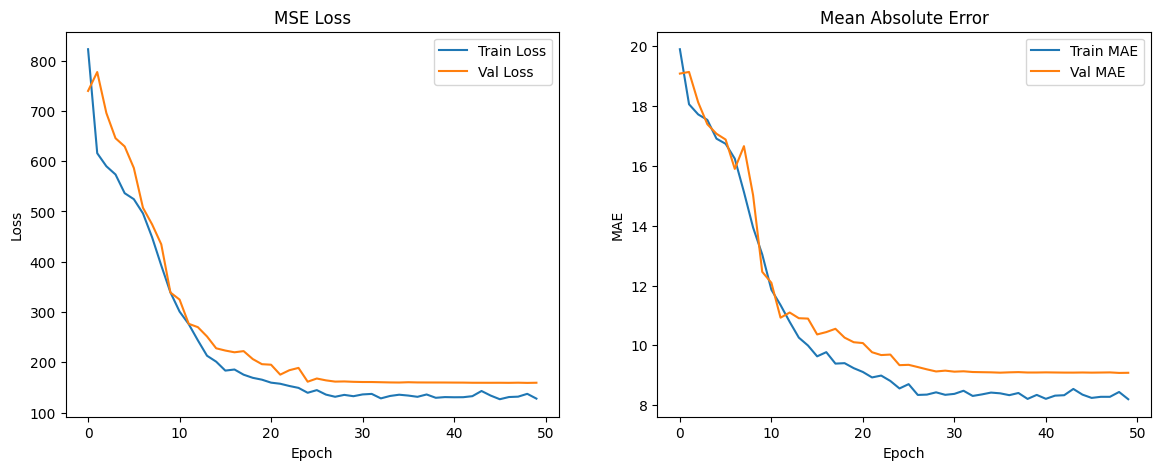

In [21]:
plt.figure(figsize=(14,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# MAE
plt.subplot(1,2,2)
plt.plot(mae, label="Train MAE")
plt.plot(val_mae, label="Val MAE")
plt.title("Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()


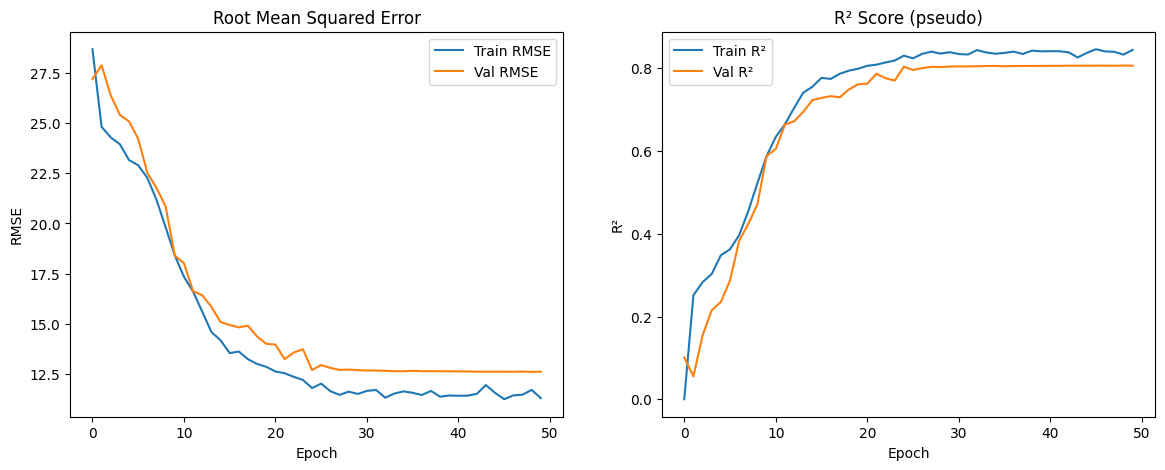

In [22]:
plt.figure(figsize=(14,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(rmse, label="Train RMSE")
plt.plot(val_rmse, label="Val RMSE")
plt.title("Root Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()

# R²
plt.subplot(1,2,2)
plt.plot(r2, label="Train R²")
plt.plot(val_r2, label="Val R²")
plt.title("R² Score (pseudo)")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()

plt.show()


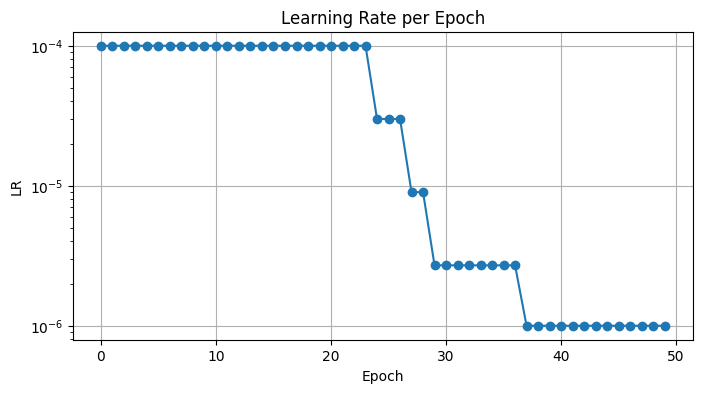

In [23]:
plt.figure(figsize=(8,4))
plt.plot(lr, marker='o')
plt.title("Learning Rate per Epoch")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.yscale("log")
plt.grid(True)
plt.show()


In [28]:
preds = model.predict(train_ds, verbose=1)
preds = preds.reshape(-1)  # flatten to (N,)
print(preds[:10])


119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step
[23.609705   6.4202666 26.82216    9.838393  27.8212    20.662428
 36.98593    3.9408436 32.89293    5.7627506]


Prediction stats:
min: 2.3867269
max: 115.98208
mean: 23.771017
std: 22.887058


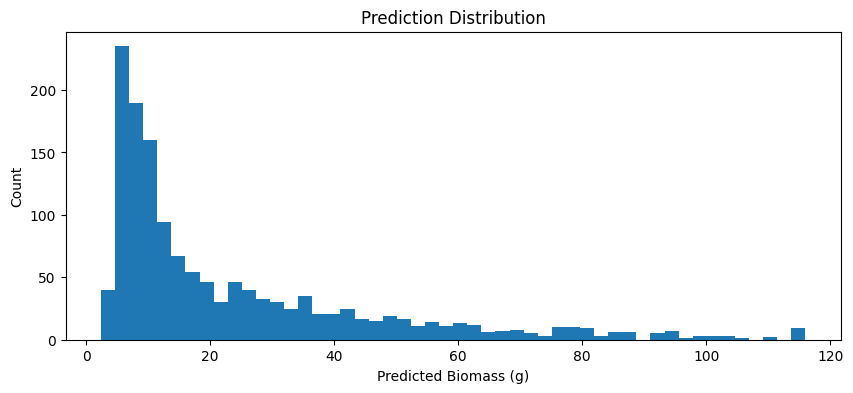

High clip threshold: 115.71722


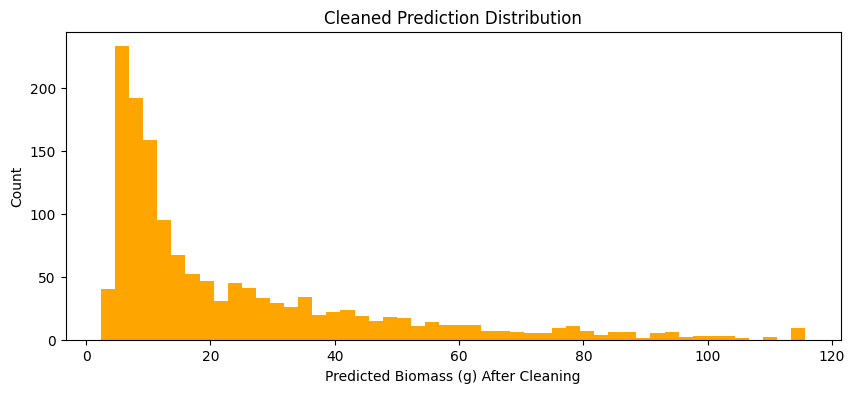

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# A. Analyze prediction distribution
# ---------------------------
print("Prediction stats:")
print("min:", preds.min())
print("max:", preds.max())
print("mean:", preds.mean())
print("std:", preds.std())

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50)
plt.title("Prediction Distribution")
plt.xlabel("Predicted Biomass (g)")
plt.ylabel("Count")
plt.show()

# ---------------------------
# B. Clip NEGATIVE predictions (biomass can't be < 0)
# ---------------------------
preds = np.clip(preds, 0, None)

# ---------------------------
# C. Handle extreme OUTLIERS
# Strategy:
#   - Compute 99.5th percentile
#   - Soft-limit anything above it
# ---------------------------
high_thresh = np.percentile(preds, 99.5)
print("High clip threshold:", high_thresh)

preds[preds > high_thresh] = high_thresh

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50, color='orange')
plt.title("Cleaned Prediction Distribution")
plt.xlabel("Predicted Biomass (g) After Cleaning")
plt.ylabel("Count")
plt.show()

